### Importa os pacotes de sistema, análise, visualização, teste, ML e explainer

In [2]:
!pip install shap

In [3]:
!pip install --upgrade numpy==1.24

In [4]:
import numpy
import shap

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
## for data
import pandas as pd
import numpy as np
## for plotting
import matplotlib.pyplot as plt
import seaborn as sns
## for statistical tests
import scipy
import statsmodels.formula.api as smf
import statsmodels.api as sm
## for machine learning
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
## for explainer
from lime import lime_tabular

In [6]:
#ESSE É O PARAMETRO QUE VAI INICIALIZAR AS SEMENTES DE MODELOS, SPLITTERS DE CONJUNTO DE TESTE/TREINAMENTO. 
#SERVE PRA TER UM MESMO RESULTADO AO VOCE USAR UM MESMO VALOR
roll_dice=0

### Ingere os dados baixados do git do Fake.BR Corpus

Notícias e target

In [7]:
lista_strings_fake = list()
lista_strings_true = list()

path_fake_news = "Fake.br-Corpus-master/full_texts/fake/"
path_true_news = "Fake.br-Corpus-master/full_texts/true/"

lista_arquivos_fake = os.listdir(path_fake_news)
lista_fake = [1] * len(lista_arquivos_fake)
lista_arquivos_true = os.listdir(path_true_news)
lista_true  = [0] * len(lista_arquivos_true)

for arquivo in lista_arquivos_fake:
    with open(path_fake_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake.append(lines)
for arquivo in lista_arquivos_true:
    with open(path_true_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true.append(lines)
df_fake = pd.DataFrame([lista_strings_fake, lista_fake]).T
df_true = pd.DataFrame([lista_strings_true, lista_true]).T
df = pd.concat([df_fake, df_true])

Features

In [8]:
lista_strings_fake_meta_information = list()
lista_strings_true_meta_information = list()

path_fake_features = "Fake.br-Corpus-master/full_texts/fake-meta-information/"
path_true_features = "Fake.br-Corpus-master/full_texts/true-meta-information/"

lista_arquivos_fake_meta_information = os.listdir(path_fake_features)
lista_fake_meta_information = [1] * len(lista_arquivos_fake_meta_information)
lista_arquivos_true_meta_information = os.listdir(path_true_features)
lista_true_meta_information  = [0] * len(lista_arquivos_true_meta_information)

for arquivo in lista_arquivos_fake_meta_information:
    with open(path_fake_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake_meta_information.append(lines)
for arquivo in lista_arquivos_true_meta_information:
    with open(path_true_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true_meta_information.append(lines)
    
df_fake_meta_information = pd.DataFrame([lista_strings_fake_meta_information, lista_fake_meta_information]).T
df_true_meta_information = pd.DataFrame([lista_strings_true_meta_information, lista_true_meta_information]).T
df_meta_information = pd.concat([df_fake_meta_information, df_true_meta_information])

Desempacota as features da lista em colunas diferentes do df de features

In [9]:
df_meta_information['author']=df_meta_information[0].apply(lambda i:i[0])
df_meta_information['link']=df_meta_information[0].apply(lambda i:i[1])
df_meta_information['category']=df_meta_information[0].apply(lambda i:i[2])
df_meta_information['date_of_publication']=df_meta_information[0].apply(lambda i:i[3])
df_meta_information['number_of_tokens']=df_meta_information[0].apply(lambda i:i[4])
df_meta_information['number_of_words_without_punctuation']=df_meta_information[0].apply(lambda i:i[5])
df_meta_information['number_of_types']=df_meta_information[0].apply(lambda i:i[6])
df_meta_information['number_of_links_inside_the_news']=df_meta_information[0].apply(lambda i:i[7])
df_meta_information['number_of_words_in_upper_case']=df_meta_information[0].apply(lambda i:i[8])
df_meta_information['number_of_verbs']=df_meta_information[0].apply(lambda i:i[9])
df_meta_information['number_of_subjuntive_and_imperative_verbs']=df_meta_information[0].apply(lambda i:i[10])
df_meta_information['number_of_nouns']=df_meta_information[0].apply(lambda i:i[11])
df_meta_information['number_of_adjectives']=df_meta_information[0].apply(lambda i:i[12])
df_meta_information['number_of_adverbs']=df_meta_information[0].apply(lambda i:i[13])
df_meta_information['number_of_modal_verbs']=df_meta_information[0].apply(lambda i:i[14])
df_meta_information['number_of_singular_first_and_second_personal_pronouns']=df_meta_information[0].apply(lambda i:i[15])
df_meta_information['number_of_plural_first_personal_pronouns']=df_meta_information[0].apply(lambda i:i[16])
df_meta_information['number_of_pronouns']=df_meta_information[0].apply(lambda i:i[17])
df_meta_information['pausality']=df_meta_information[0].apply(lambda i:i[18])
df_meta_information['number_of_characters']=df_meta_information[0].apply(lambda i:i[19])
df_meta_information['average_sentence_length']=df_meta_information[0].apply(lambda i:i[20])
df_meta_information['average_word_length']=df_meta_information[0].apply(lambda i:i[21])
df_meta_information['percentage_of_news_with_speeling_errors']=df_meta_information[0].apply(lambda i:i[22])
df_meta_information['emotiveness']=df_meta_information[0].apply(lambda i:i[23])
df_meta_information['diversity']=df_meta_information[0].apply(lambda i:i[24])

Trata tipologia dos dados

In [10]:
df_meta_information

,0,1,author,link,category,date_of_publication,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,"[mrk\n, https://ceticismopolitico.com/2017/11/...",1,mrk\n,https://ceticismopolitico.com/2017/11/30/katia...,politica\n,2017-11-30\n,211\n,185\n,120\n,0\n,...,2\n,0\n,26\n,2.0\n,815\n,14.2308\n,4.40541\n,0.0\n,0.263158\n,0.648649
1,"[None\n, https://ceticismopolitico.com/2017/11...",1,None\n,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica\n,2017-11-24\n,289\n,254\n,163\n,0\n,...,1\n,0\n,20\n,2.5\n,1205\n,18.1429\n,4.74409\n,0.00787402\n,0.241667\n,0.641732
2,"[None\n, https://afolhabrasil.com.br/politica/...",1,None\n,https://afolhabrasil.com.br/politica/reinaldo-...,politica\n,2017-05-23\n,304\n,275\n,170\n,0\n,...,0\n,0\n,18\n,1.8125\n,1344\n,17.1875\n,4.88727\n,0.00363636\n,0.12782\n,0.618182
3,"[None\n, https://www.diariodobrasil.org/relato...",1,None\n,https://www.diariodobrasil.org/relatorio-assus...,politica\n,24/07/2017\n,639\n,572\n,316\n,1\n,...,0\n,0\n,34\n,2.68\n,3122\n,22.88\n,5.45804\n,0.00174825\n,0.229008\n,0.552448
4,"[None\n, https://www.diariodobrasil.org/radial...",1,None\n,https://www.diariodobrasil.org/radialista-amer...,politica\n,25/07/2017\n,128\n,111\n,82\n,0\n,...,1\n,0\n,12\n,0.894737\n,515\n,5.84211\n,4.63964\n,0.0\n,0.269231\n,0.738739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,"[ Célia Froufe, correspondente, O Estado de S....",0,"Célia Froufe, correspondente, O Estado de S.P...","http://politica.estadao.com.br/noticias/geral,...",politica\n,22 de novembro de 2016 \n,637\n,567\n,291\n,0\n,...,0\n,0\n,27\n,3.5\n,2708\n,28.35\n,4.77601\n,0.00176367\n,0.141176\n,0.513228
3596,"[ Por G1, Brasília \n, https://g1.globo.com/po...",0,"Por G1, Brasília \n",https://g1.globo.com/politica/noticia/temer-di...,politica\n,09/02/2018 08h25 \n,1115\n,949\n,399\n,0\n,...,7\n,2\n,43\n,3.01818\n,4520\n,17.2545\n,4.76291\n,0.00210748\n,0.22871\n,0.420443
3597,"[ Por Luciana Amaral, G1, Brasília \n, https:/...",0,"Por Luciana Amaral, G1, Brasília \n",https://g1.globo.com/politica/noticia/os-obsta...,politica\n,31/12/2016 05h00 \n,1698\n,1463\n,607\n,0\n,...,0\n,0\n,65\n,3.50746\n,7142\n,21.8358\n,4.88175\n,0.0\n,0.245955\n,0.414901
3598,"[ Por G1 \n, https://g1.globo.com/resumo-do-di...",0,Por G1 \n,https://g1.globo.com/resumo-do-dia/noticia/sex...,sociedade_cotidiano\n,15/09/2017 20h46 \n,742\n,648\n,398\n,None\n,...,1\n,2\n,31\n,2.76471\n,3003\n,19.0588\n,4.63426\n,0.00154321\n,0.1843\n,0.614198


In [11]:
df_features = pd.DataFrame()
for col in df_meta_information.columns[2:]:
    df_features[col]=df_meta_information[col].str.replace('\n','')

In [12]:
df_features[df_features.columns[4:]]=df_features[df_features.columns[4:]].apply(lambda i:pd.to_numeric(i,errors='coerce'))

In [13]:
def arruma_data(date):
    to_be = ['/','01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'];
    as_is = [' de ', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']; 
    for word in range(len(to_be)):
        date=date.replace(as_is[word],to_be[word])
    return date

In [14]:
df_features["date_of_publication"]=df_features["date_of_publication"].apply(lambda i:arruma_data(i))

In [15]:
df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)

C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\1103604670.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)


In [16]:
#df_features[df_features["date_of_publication"].isna()]

Concatena as tabelas de notícia e target com a de features

In [17]:
df_noticia=df.reset_index().reset_index()
del df_noticia['index']
df_noticia=df_noticia.rename(columns={'level_0':'id_noticia',0:'noticia',1:'fake'})
df_noticia['noticia']=df_noticia['noticia'].apply(lambda i:' '.join(linha.strip() for linha in i))

In [18]:
df_features=df_features.reset_index()
del df_features['index']

In [19]:
base=pd.concat([df_noticia,df_features],axis=1)
#base.head(3)

## Conteúdo como embeddings densos (BERTimbau)

Em vez das 21 features lingüísticas manuais, o Conteúdo desta versão é representado por embeddings de sentença do **BERTimbau** (`neuralmind/bert-base-portuguese-cased`, 768 dimensões), um BERT treinado do zero em português brasileiro. As features de Contexto (fonte/autor/data) continuam exatamente as mesmas dos outros dois notebooks.

Avisos:
- O modelo aceita até **512 tokens** (tokenização WordPiece, subpalavras). Com média de ~640 palavras por artigo no Fake.BR, a maioria dos textos passa de 512 subword tokens — artigos muito longos ainda perdem o final, mas a cobertura é drasticamente maior que os 128 tokens do MiniLM anterior.
- BERTimbau é um modelo BERT bruto (sem fine-tuning para similaridade de sentença). O `SentenceTransformer` aplica mean pooling sobre os tokens para produzir o vetor de sentença. A geometria do espaço de embedding pode ser menos isotrópica que a de modelos treinados com objetivos contrastivos (ex: paraphrase-MiniLM), o que pode afetar classificadores downstream — mas o ganho de cobertura de contexto justifica o teste.
- 768 dimensões em vez de 384: o espaço de feature dobra, o que pode tornar o CV mais lento (especialmente SVM e Rede Neural).
- A primeira execução baixa os pesos do BERTimbau (~440MB) do Hugging Face e pode demorar dependendo da conexão. Encodar ~7.200 notícias com 512 tokens em CPU é consideravelmente mais lento que o MiniLM (atenção escala com O(n²) em relação ao comprimento da sequência).


In [20]:
colunas_linguisticas = [c for c in df_features.columns if c not in ('author', 'link', 'category', 'date_of_publication')]
base = base.drop(columns=colunas_linguisticas)
base.columns.tolist()


['id_noticia',
 'noticia',
 'fake',
 'author',
 'link',
 'category',
 'date_of_publication']

In [21]:
!pip install sentence-transformers


In [22]:
import torch
import time
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    props = torch.cuda.get_device_properties(0)
    livre = props.total_memory - torch.cuda.memory_reserved(0)
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  CC: {props.major}.{props.minor}')
    print(f'  VRAM total: {props.total_memory / 1024**3:.1f} GB')
    print(f'  VRAM livre estimada: {livre / 1024**3:.1f} GB')

# BERTimbau carregado via sentence-transformers com mean pooling automático.
# max_seq_length definido explicitamente para garantir uso dos 512 tokens do BERT.
model_st = SentenceTransformer('neuralmind/bert-base-portuguese-cased', device=device)
model_st.max_seq_length = 512

print('dimensao do embedding:', model_st.get_sentence_embedding_dimension())
print('max_seq_length:', model_st.max_seq_length)


Dispositivo: cuda
  GPU: NVIDIA GeForce GTX 1050 Ti
  CC: 6.1
  VRAM total: 4.0 GB
  VRAM livre estimada: 4.0 GB


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19894.80it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


dimensao do embedding: 768
max_seq_length: 512


C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\2203186232.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('dimensao do embedding:', model_st.get_sentence_embedding_dimension())


In [23]:
# GPU (4 GB VRAM): batch_size reduzido para evitar OOM com sequências de 512 tokens.
# Se ainda ocorrer OOM, reduza para 4.
batch_size = 8 if device == 'cuda' else 16

inicio = time.time()
embeddings = model_st.encode(base['noticia'].tolist(), batch_size=batch_size, show_progress_bar=True)
df_embeddings = pd.DataFrame(embeddings, columns=[f'emb_{i}' for i in range(embeddings.shape[1])], index=base.index)
print(f"Encoding concluído em {time.time()-inicio:.1f}s para {len(df_embeddings)} notícias (device={device}, batch={batch_size})")

for col in df_embeddings.columns:
    base[col] = df_embeddings[col]

base[df_embeddings.columns].head()


Batches: 100%|██████████| 900/900 [09:03<00:00,  1.66it/s]
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[col] = df_embeddings[col]
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[col] = df_embeddings[col]
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which

Encoding concluído em 543.8s para 7200 notícias (device=cuda, batch=8)


C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[col] = df_embeddings[col]
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base[col] = df_embeddings[col]
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\3667616844.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,-0.217952,0.073862,0.285715,-0.061354,0.310578,0.190762,0.016645,0.135120,-0.063239,-0.188660,...,0.103520,-0.087039,-0.426799,-0.384058,0.351691,-0.409136,0.214951,0.064422,-0.146491,-0.294537
1,-0.062288,-0.049124,0.212886,0.066954,0.178847,0.162551,0.033856,0.132623,-0.128620,-0.240290,...,0.096756,-0.225054,-0.259319,-0.369333,0.322718,-0.407347,0.128029,0.048479,-0.174804,-0.253921
2,-0.099852,-0.127006,0.375452,0.063376,0.316564,0.472117,0.133435,0.236595,-0.111181,0.089689,...,0.184661,-0.017644,-0.438214,-0.257635,0.537126,-0.383183,0.064880,-0.008473,-0.232525,-0.324197
3,-0.069027,-0.081821,0.414751,0.037729,0.230119,0.246170,0.037059,0.116920,-0.078883,-0.349116,...,0.145765,-0.137805,-0.528651,-0.465070,0.345654,-0.430209,0.180905,0.157452,-0.110989,-0.265809
4,-0.195541,-0.097206,0.193747,0.046832,0.347179,0.171673,-0.055388,0.088075,0.028900,-0.307872,...,0.234202,-0.006784,-0.301776,-0.294823,0.324234,-0.546023,0.285332,0.034592,-0.107818,-0.385217


## Feature Engineering

Extrai as Fontes da informação a partir da URL

In [24]:
# Extract site names using regular expressions
base['source']=base['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]




C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\147339836.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base['source']=base['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]


In [25]:

base['source'] = base['source'].apply(lambda i: "estadao.com.br" if "estadao" in i else "folha.com.br" if "folha" in i and "uol" in i else i)

In [26]:
base['source'].value_counts()

source
diariodobrasil.org                 3337
g1.globo.com                       2300
estadao.com.br                     1203
afolhabrasil.com.br                 174
folha.com.br                         95
thejornalbrasil.com.br               66
ceticismopolitico.com                16
topfivetv.com                         7
territorioeldorado.limao.com.br       2
Name: count, dtype: int64

Traz as features da data

In [27]:
from datetime import datetime

In [28]:
base["date_of_publication"] = base["date_of_publication"].fillna(np.mean(base["date_of_publication"])).apply(lambda i:int(i.timestamp()))

Traz feature de Autor

In [29]:
base['author']=base['author'].apply(lambda i: 0 if i=='None' else 1)

Transforma feature de Categoria em Número

In [30]:
base.columns

Index(['id_noticia', 'noticia', 'fake', 'author', 'link', 'category',
       'date_of_publication', 'emb_0', 'emb_1', 'emb_2',
       ...
       'emb_759', 'emb_760', 'emb_761', 'emb_762', 'emb_763', 'emb_764',
       'emb_765', 'emb_766', 'emb_767', 'source'],
      dtype='object', length=776)

In [31]:
base = base.drop(['link'],axis=1)

### Análise exploratória dos dados

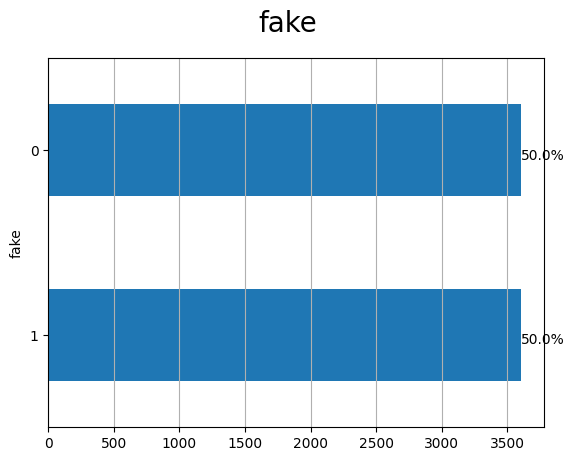

In [32]:
y = "fake"
ax = base[y].value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
ax.grid(axis="x")
plt.suptitle(y, fontsize=20)
plt.show()

C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\729831717.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\729831717.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

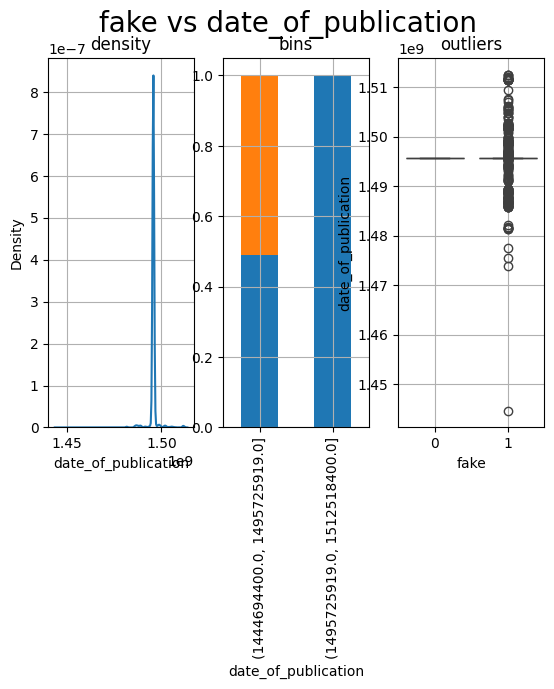

In [33]:
cat, num = "fake", "date_of_publication"
fig, ax = plt.subplots(nrows=1, ncols=3,  sharex=False, sharey=False)

# CORREÇÃO 1: Trocando 'x' e 'y' por 'cat' e 'num' (usando f-strings para facilitar)
fig.suptitle(f"{cat} vs {num}", fontsize=20)

### distribution
ax[0].title.set_text('density')
for i in base[cat].unique():
    # Aviso: sns.distplot está obsoleto nas versões mais recentes do seaborn, 
    # se der erro no futuro, troque por sns.kdeplot(...) ou sns.histplot(..., kde=True)
    sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
ax[0].grid(True)

### stacked
ax[1].title.set_text('bins')
breaks = np.quantile(base[num], q=np.linspace(0,1,11))
tmp = base.groupby([cat, pd.cut(base[num], breaks, duplicates='drop')]).size().unstack().T
tmp = tmp[base[cat].unique()]
tmp["tot"] = tmp.sum(axis=1)
for col in tmp.drop("tot", axis=1).columns:
    tmp[col] = tmp[col] / tmp["tot"]
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot
ax[2].title.set_text('outliers')
# CORREÇÃO 2: Substituindo sns.catplot por sns.boxplot
sns.boxplot(x=cat, y=num, data=base, ax=ax[2]) 
ax[2].grid(True)

plt.show()

### Testes de hipótese

In [34]:
base = base.set_index(['id_noticia','noticia'])
base['fake'] = base['fake'].astype(int)

Para as variaveis categoricas

In [35]:
from scipy.stats import chi2_contingency, fisher_exact, pointbiserialr,ttest_ind
for i in ['category','author','source']:
    # Create a contingency table
    contingency_table = pd.crosstab(base['fake'], base[i])
    
    # Perform Chi-square test of independence
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print("p-value:", p_value)
    if p_value<.05:
        print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
    else:
        print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
        base= base.drop('category',axis=1)

p-value: 1.0
A variável category não é correlacionada com a veracidade da informação e será descartada
p-value: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value: 0.0
A variável source é correlacionada com a veracidade da informação e será mantida


Para as contínuas

In [36]:
for i in [col for col in base.columns[1:] if not col.startswith('emb_')]:
    if i!='category' and i.startswith('source')==False:
        # Separate the continuous variable by the fake groups
        group_0 = base[base['fake'] == 0][i]
        group_1 = base[base['fake'] == 1][i]
        
        # Perform Point-Biserial correlation
        correlation_coefficient, p_value_point_biserial = pointbiserialr(base['fake'], base[i])
        print("p-value Point BIserial Test:", p_value_point_biserial)
        
        # Perform independent samples t-test
        t_statistic, p_value_ttest = ttest_ind(group_0, group_1)
        
        print("p-value Ttest:", p_value_ttest)
        
        if p_value_ttest<.05 and p_value_point_biserial<.05:
            print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
        else:
            print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
            base= base.drop(i,axis=1)

p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.9999993945052402
p-value Ttest: 0.9999993945037162
A variável date_of_publication não é correlacionada com a veracidade da informação e será descartada


c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


As dimensões de embedding (`emb_*`) não passam pelo filtro de significância marginal acima — cada dimensão isoladamente não tem leitura interpretável (não é "número de verbos"), então testar significância dimensão a dimensão arriscaria descartar sinal que só é útil de forma conjunta. Todas as 768 dimensões são mantidas. Pelo mesmo motivo, o heatmap de correlação usado nos outros dois notebooks para essa decisão não se aplica aqui (seria ilegível e sem leitura útil em ~770 colunas).


In [37]:
## Convert categorical variable to dummy variables
dummies = pd.get_dummies(base['source'], prefix='source', drop_first=True)

# Concatenate dummy variables with original dataframe
base = pd.concat([base, dummies], axis=1)

del base['source']

## Separação do conjunto de teste e de treinamento

In [38]:
## split data
df_train, df_test = model_selection.train_test_split(base, 
                      test_size=0.3,random_state=roll_dice)
## print info
print("X_train shape:", df_train.drop("fake",axis=1).shape, "| X_test shape:", df_test.drop("fake",axis=1).shape)
print("y_train mean:", round(np.mean(df_train["fake"]),2), "| y_test mean:", round(np.mean(df_test["fake"]),2))
print(df_train.shape[1], "features:", df_train.drop("fake",axis=1).columns.to_list())

X_train shape: (5040, 777) | X_test shape: (2160, 777)
y_train mean: 0.5 | y_test mean: 0.5
778 features: ['author', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_54', 'emb_55', 'emb_56', 'emb_57', 'emb_58', 'emb_59', 'emb_60', 'emb_61', 'emb_62', 'emb_63', 'emb_64', 'emb_65', 'emb_66', 'emb_67', 'emb_68', 'emb_69', 'emb_70', 'emb_71', 'emb_72', 'emb_73', 'emb_74', 'emb_75', 'emb_76', 'emb_77', 'emb_78', 'emb_79', 'emb_80', 'emb_81', 'emb_82', 'emb_83', 'emb_84', 'emb_85', 'emb_86', 'emb_87', 'emb_88', 'em

### Escala a base de dados

In [39]:
train_scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = train_scaler.fit_transform(df_train.drop('fake',axis=1))
df_train_scaled= pd.DataFrame(X, columns=df_train.drop('fake',axis=1).columns, index=df_train.index)
df_train_scaled["fake"] = df_train["fake"]
df_train_scaled["fake"] = df_train_scaled["fake"].astype('int')

In [40]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_test.drop('fake',axis=1))
df_test_scaled= pd.DataFrame(X, columns=df_test.drop('fake',axis=1).columns, index=df_test.index)
df_test_scaled["fake"] = df_test["fake"]
df_test_scaled["fake"] = df_test_scaled["fake"].astype('int')

In [41]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Import other classifiers you want to test

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Create a dictionary to store the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=roll_dice),
    'Decision Tree': DecisionTreeClassifier(random_state=roll_dice),
    'Random Forest': RandomForestClassifier(random_state=roll_dice),
    'Gradient Boosting': GradientBoostingClassifier(random_state=roll_dice),
    'AdaBoost': AdaBoostClassifier(random_state=roll_dice),
    'Support Vector Machine': SVC(probability=True,random_state=roll_dice),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(random_state=roll_dice, max_iter=600),
    'Naive Bayes': GaussianNB()
}

In [42]:
X_train = df_train_scaled[[col for col in df_train_scaled.columns if col!='fake']].fillna(0).values
y_train = df_train['fake'].values.astype('int')
X_test = df_test_scaled[[col for col in df_test_scaled.columns if col!='fake']].fillna(0).values
y_test = df_test['fake'].values.astype('int')

In [43]:
def get_cross_validation_results(Xtrain, ytrain):
    results = {}
    kfold = KFold(n_splits=5, shuffle=True, random_state=roll_dice)  # 5-fold cross-validation
    
    for name, clf in classifiers.items():
        scores = cross_val_score(clf, Xtrain, ytrain, cv=kfold, scoring='accuracy')
        results[name] = scores.mean()
    return results

In [44]:
def get_best_model(Xtrain,ytrain):
    results = get_cross_validation_results(Xtrain, ytrain)
    results = pd.DataFrame(results.items(),columns=['model','accuracy']).set_index('model')
    best_model_name=results.index[results['accuracy'].argmax()]
    best_model = classifiers[best_model_name]
    best_model.fit(Xtrain, ytrain)
    return results, best_model_name,best_model

### Observação: Só dá certo se o modelo não for o NB

In [45]:
def get_feature_importances(df_train):
    X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    y_train = df_train['fake'].values.astype('int')
    results,best_model_name,best_model = get_best_model(X_train,y_train)
    best_model.fit(X_train,y_train)
    if best_model_name!='Support Vector Machine':
        if best_model_name=="Logistic Regression":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coef_[0]), columns=['variavel','importancia'])
        elif  best_model_name== "Neural Network":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coefs_[0]), columns=['variavel','importancia'])
        
        else:
             importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.feature_importances_), columns=['variavel','importancia'])
                
        importancias['importancia_abs']= importancias['importancia'].apply(lambda i:np.abs(i)).all().sort_values(ascending=False)
        importancias ['expressividade absoluta']=importancias['importancia_abs']/importancias['importancia_abs'].sum()
        importancias ['expressividade para a classe']=importancias['importancia'].apply(calculate_share(importancias,'importancia'))
        importancias['classe'] = importancias['importancia'].apply(lambda i:True if i<0 else False)   
    
    else:
        importancias = "Não existe um método direto de importancia de features para Maquinas de Vetor de Suporte. Tente usar a análise SHAP"

    
    return best_model_name, best_model,importancias

In [46]:
def calculate_share(df, column_name):
    column = df[column_name]
    positive_sum = column[column > 0].sum()
    negative_sum = column[column < 0].sum()

    def calculate_share_helper(value):
        if value > 0:
            return value / positive_sum if positive_sum != 0 else 0
        elif value < 0:
            return value / negative_sum if negative_sum != 0 else 0
        else:
            return 0

    return calculate_share_helper

In [47]:
def get_test_results(model_name,model,X_train,X_test, y_train,y_test,iteration_name="All variables"): 
    #X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    #y_train = df_train['fake'].values.astype('int')
    #X_test= df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values
    #y_test = df_test['fake'].values.astype('int')
    ## train
    model.fit(X_train, y_train)
    ## test
    y_pred = model.predict(X_test)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
    
    # Assuming you have the best model stored as 'best_model' and the test dataset as 'Xtest' and 'ytest'
    
    
    print(f"Modelo: {model_name}")
    print(f"Modelo: {model}")
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1}")
    
    # Calculate recall
    recall = recall_score(y_test, y_pred)
    print(f"Recall: {recall}")
    
    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision}")
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {iteration_name}")
    plt.savefig(f'figures/figures_embeddings/Confusion Matrix - {iteration_name}.pdf')
    plt.show()
    

## Ablação

In [48]:
df_train_scaled_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_scaled_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_scaled_context.columns or col=='fake']]
df_test_scaled_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_scaled_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_scaled_context.columns or col=='fake']]

In [49]:
df_train_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_context.columns or col=='fake']]
df_test_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_context.columns or col=='fake']]

In [50]:
X = np.vstack((df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values, df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values ))
y = list(df_train_scaled_content['fake'].values.astype('int'))+list(df_test_scaled_content['fake'].values.astype('int'))

## Conteúdo

In [51]:
X_train_content=df_train_scaled_content.reset_index()[[col for col in df_train_scaled_content.columns if col!='fake' ]].fillna(0)
y_train_content=df_train_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_test_content=df_test_scaled_content.reset_index()[[col for col in df_test_scaled_content.columns if col!='fake']].fillna(0)
y_test_content=df_test_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_content = pd.concat([X_train_content,X_test_content],axis=0)
y_content = pd.concat([y_train_content,y_test_content],axis=0)

In [52]:
content_model_results,content_model_name,content_model= get_best_model(X_train_content,y_train_content)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.975925925925926
F1 Score: 0.9761248852157943
Recall: 0.9797235023041475
Precision: 0.9725526075022873


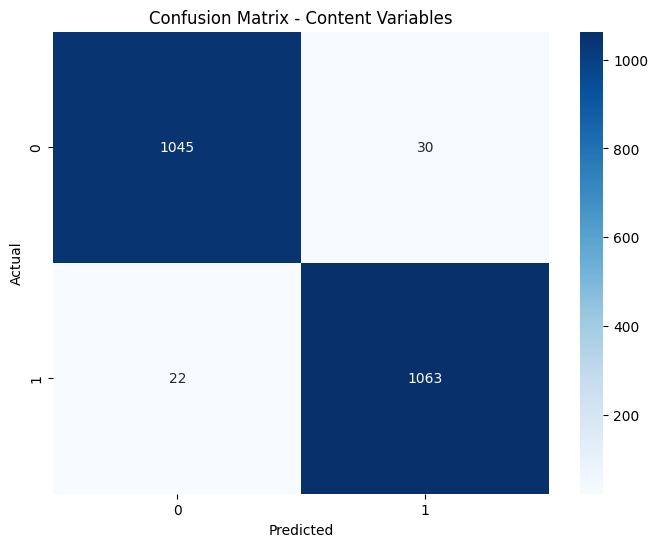

In [53]:
get_test_results(content_model_name,content_model,X_train_content,X_test_content,y_train_content,y_test_content,"Content Variables")

### Explicabilidade do Conteúdo (embeddings) — LIME

Dimensões de embedding não têm leitura humana, então SHAP sobre `emb_0..emb_383` não diria nada interpretável. Em vez disso, usamos `LimeTextExplainer`: ele trata a pipeline inteira (texto → embedding → escala → classificador) como caixa-preta de texto→probabilidade, perturbando a notícia por remoção de palavras e ajustando um modelo linear local — a explicação fica em espaço de palavras, não de dimensões.

`num_samples` reduzido de 5000 (padrão do LIME) para 500 por motivo de runtime — cada amostra perturbada exige reencodar o texto via sentence-transformers.


`train_scaler` (MinMaxScaler) escala cada coluna de forma independente (`X_scaled = X * scale_ + min_`, sem interação entre colunas). Por isso, para reescalar só as dimensões de embedding de um texto novo gerado pelo LIME, basta aplicar essa mesma fórmula restrita às posições `emb_*` — sem precisar reconstruir a linha inteira (contexto incluso) antes de chamar `.transform()`, o que evitaria escalar a parte de contexto duas vezes.


In [54]:
general_train_columns = [col for col in df_train.columns if col != 'fake']
content_train_columns = X_train_content.columns.tolist()
emb_cols = [f'emb_{i}' for i in range(model_st.get_sentence_embedding_dimension())]

emb_positions = [general_train_columns.index(c) for c in emb_cols]
emb_scale = train_scaler.scale_[emb_positions]
emb_min = train_scaler.min_[emb_positions]

def escalar_embeddings(matriz_embeddings):
    return matriz_embeddings * emb_scale + emb_min


C:\Users\Caio\AppData\Local\Temp\ipykernel_2280\889605470.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  emb_cols = [f'emb_{i}' for i in range(model_st.get_sentence_embedding_dimension())]


In [55]:
def predict_fn_content(texts):
    novos_embeddings = model_st.encode(list(texts))
    novos_embeddings_escalados = escalar_embeddings(novos_embeddings)
    novo_df = pd.DataFrame(novos_embeddings_escalados, columns=emb_cols)
    return content_model.predict_proba(novo_df[content_train_columns].values)


In [56]:
from lime.lime_text import LimeTextExplainer
from spacy.lang.pt.stop_words import STOP_WORDS as _STOP_PT
import re

# Stopwords PT (lista spaCy, ~600 palavras) excluidas da perturbacao do LIME.
# Palavras funcionais aparecem como importantes por artefato do modelo contextual:
# remover "e" muda o embedding BERT sem carregar sinal semantico fake/real.
def _lime_tokenizer(text):
    tokens = re.split(r'\W+', text)
    return [t for t in tokens if t and t.lower() not in _STOP_PT and len(t) > 1]

explainer_content_lime = LimeTextExplainer(class_names=['true', 'fake'],
                                           split_expression=_lime_tokenizer)

Escolhe, entre as notícias de treino com entre 100 e 400 palavras, a de maior confiança do modelo (predição mais afastada de 0,5). Com BERTimbau o limite é 512 tokens (subpalavras), o que corresponde a aproximadamente 350–400 palavras dependendo do texto. Textos abaixo desse limiar são representados integralmente, tornando a explicação por palavra mais fiel ao que o modelo de fato processou. O teto de 400 palavras fica bem abaixo desse limite; o piso de 100 garante diversidade suficiente de tokens para o LIME discriminar palavras com segurança.

In [57]:
candidatos_content = df_train_content.reset_index()[['id_noticia', 'noticia']].copy()
candidatos_content['n_palavras'] = candidatos_content['noticia'].str.split().apply(len)
candidatos_content = candidatos_content[
    (candidatos_content['n_palavras'] >= 150) &
    (candidatos_content['n_palavras'] <= 400)
].copy()

proba_c = content_model.predict_proba(X_train_content.loc[candidatos_content.index])[:, 1]
pred_c  = (proba_c >= 0.5).astype(int)
candidatos_content['confianca'] = np.abs(proba_c - 0.5)
# Verdadeiros positivos: noticia fake (label=1) corretamente classificada como fake (pred=1)
candidatos_content = candidatos_content[
    (pred_c == 1) &
    (y_train_content.loc[candidatos_content.index].values == 1)
]
candidatos_content = candidatos_content.sort_values('confianca', ascending=False)

id_exemplo_content = candidatos_content.iloc[0]['id_noticia']
texto_exemplo_content = candidatos_content.iloc[0]['noticia']
print(f"id_noticia={id_exemplo_content}, n_palavras={candidatos_content.iloc[0]['n_palavras']}, confianca={candidatos_content.iloc[0]['confianca']:.3f}")

id_noticia=1858, n_palavras=180, confianca=0.500


c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


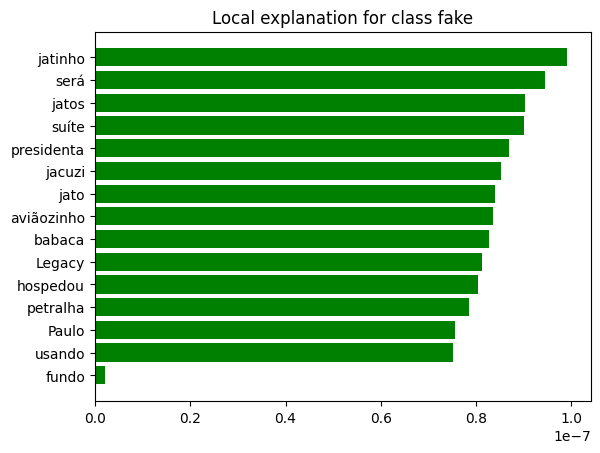

--------------------------------------------------------------------------------
Noticia selecionada (id=1858)
--------------------------------------------------------------------------------
Dilma continua zombando do contribuinte brasileiro e usando jatinho da FAB.
Dilma continua se fazendo de sonsa e "mamando" nas mordomias às custas do povo
brasileiro.  A "presidenta" que não é presidenta foi para São Paulo participar
de um evento petralha em voo fretado pelo PT (obviamente pago com dinheiro
público usando o fundo partidário) e voltou para Brasília em aviãozinho da FAB
mesmo após o decreto que restringe seu deslocamento. Ela usou um jato Legacy da
FAB para voltar a Brasília. Dilma está se valendo da interpretação de que tem o
direito de usar jatos da FAB quando voar de volta para casa. Sendo assim,  a
petista poderá ir para qualquer lugar do planeta e sua volta será sempre bancada
pelo babaca do contribuinte brasileiro. Durante a estadia em São Paulo,  Dilma
se hospedou na suíte pr

In [58]:
# Refit defensivo: garante content_model com features de embedding (768 dims)
# antes do LIME — outra celula pode ter refitado o mesmo objeto com context features.
content_model.fit(X_train_content, y_train_content)

explicacao_content = explainer_content_lime.explain_instance(
    texto_exemplo_content, predict_fn_content, num_features=15, num_samples=5000
)
explicacao_content.as_pyplot_figure()
plt.savefig(f'figures/figures_embeddings/lime_content_{id_exemplo_content}.pdf')
plt.show()


import textwrap
print("-" * 80)
print(f"Noticia selecionada (id={id_exemplo_content})")
print("-" * 80)
print(textwrap.fill(texto_exemplo_content, width=80))
print("-" * 80)

## Contexto

In [59]:
X_train_context=df_train_scaled_context.reset_index()[[col for col in df_train_scaled_context.columns if col!='fake']].fillna(0)
y_train_context=df_train_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_test_context=df_test_scaled_context.reset_index()[[col for col in df_test_scaled_context.columns if col!='fake']].fillna(0)
y_test_context=df_test_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_context = pd.concat([X_train_context,X_test_context],axis=0)
y_context = pd.concat([y_train_context,y_test_context],axis=0)

In [60]:
context_model_results,context_model_name,context_model= get_best_model(X_train_context,y_train_context)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.9990740740740741
F1 Score: 0.9990791896869244
Recall: 1.0
Precision: 0.9981600735970562


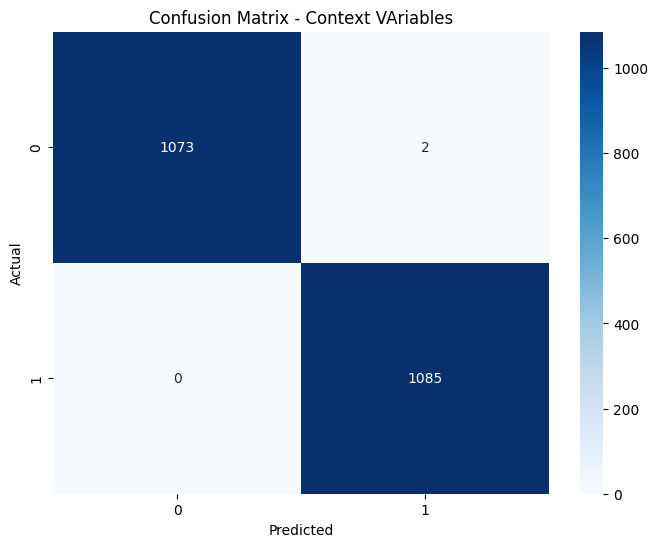

In [61]:
get_test_results(context_model_name,context_model,X_train_context,X_test_context,y_train_context,y_test_context,"Context VAriables")

In [62]:
if context_model_name!='Logistic Regression' and context_model_name!="Support Vector Machine" and context_model_name!="Neural Network":
    try:
        explainer_context = shap.TreeExplainer(context_model)
    except:
        explainer_context = shap.KernelExplainer(context_model,X_train_context)
        
elif context_model_name =='Support Vector Machine' or  context_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return context_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_context = shap.Explainer(predict_wrapper, X_train_context)
    #explainer_context = shap.KernelExplainer(context_model.predict_proba(X_context)[:,1],X_context)
    
else:
    explainer_context = shap.LinearExplainer(context_model,X_train_context)

shap_values_context = explainer_context.__call__(X_context)

# shap >=0.45 retorna uma dimensao extra por classe no TreeExplainer p/ classificadores binarios
if shap_values_context.values.ndim == 3:
    shap_values_context = shap_values_context[..., 1]

### Explicação de todas as noticias junto

In [63]:
df_train_context.reset_index().query("id_noticia==5753")['noticia']

1717    Número de mortos após tremor na fronteira entr...
Name: noticia, dtype: object

In [64]:
y_context.iloc[1717]

0

In [65]:
shap.force_plot(base_value=shap_values_context.base_values[1717],shap_values=shap_values_context.values[1717],features=np.round(shap_values_context.data[1717],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_5753.pdf")

In [66]:
df_test_context.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; qu...
Name: noticia, dtype: object

In [67]:
y_context.iloc[865]

0

In [68]:
shap.force_plot(base_value=shap_values_context.base_values[865],shap_values=shap_values_context.values[865],features=np.round(shap_values_context.data[865],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_4946.pdf")

In [69]:
df_train_context.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser ...
Name: noticia, dtype: object

In [70]:
y_context.iloc[672]

1

In [71]:
shap.force_plot(base_value=shap_values_context.base_values[672],shap_values=shap_values_context.values[672],features=np.round(shap_values_context.data[672],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_3010.pdf")

In [72]:
#shap.force_plot(explainer_context.expected_value, shap_values_context,X_context.columns)

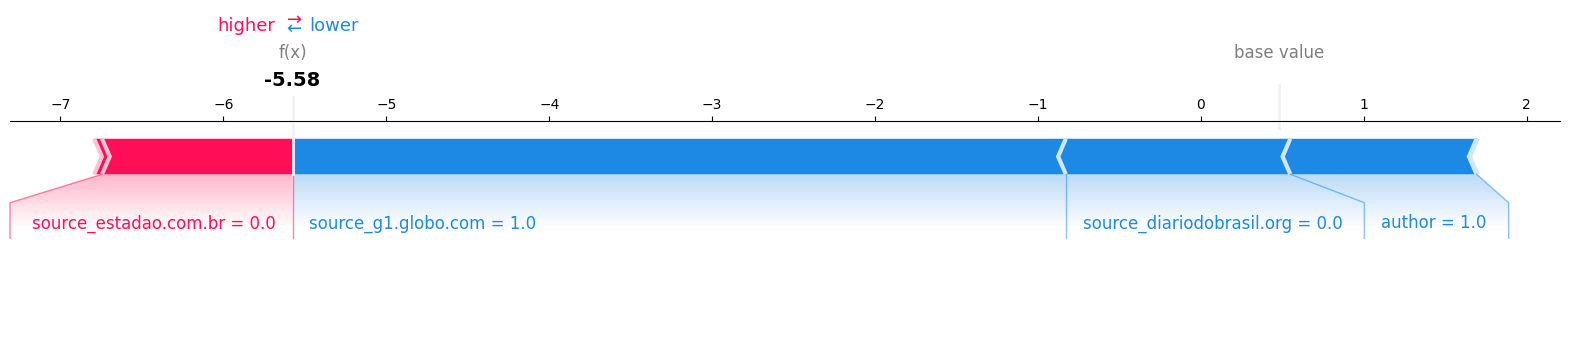

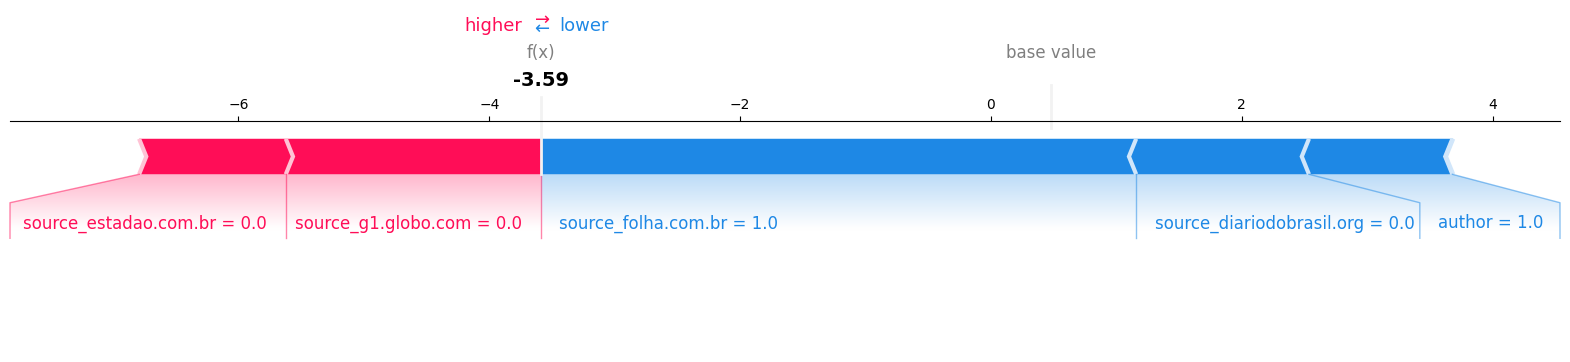

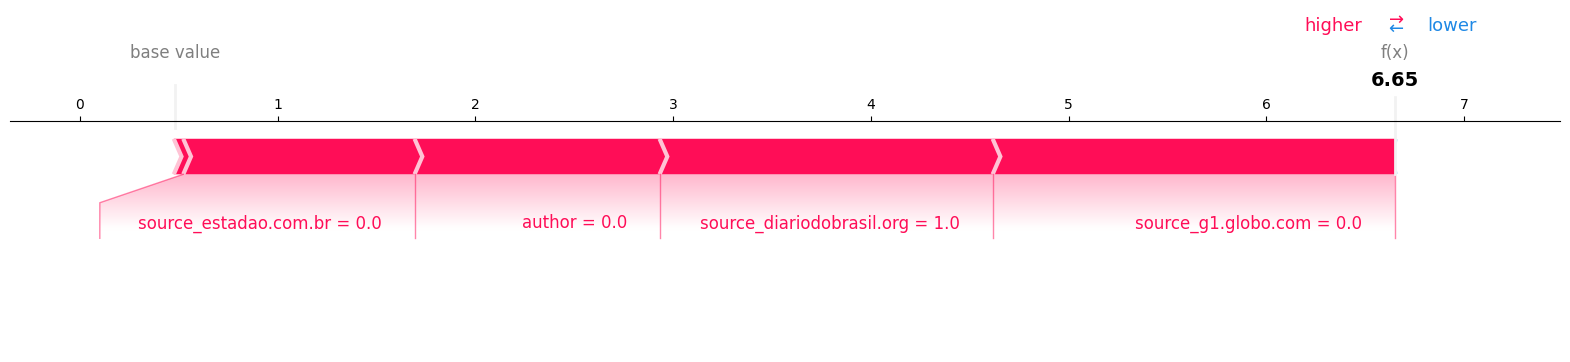

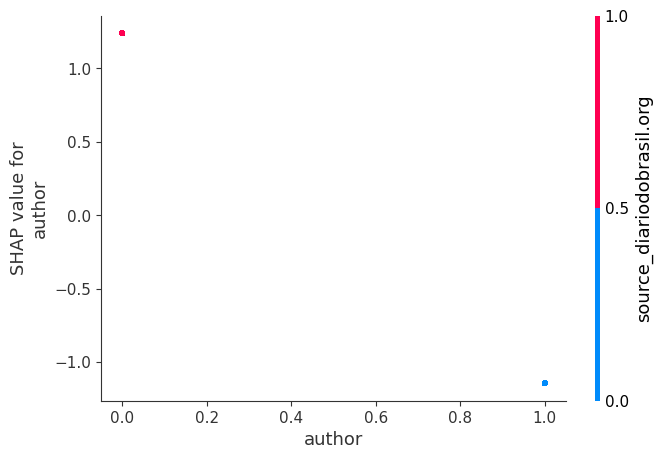

In [73]:
shap.dependence_plot('author', shap_values_context.values, X_context)

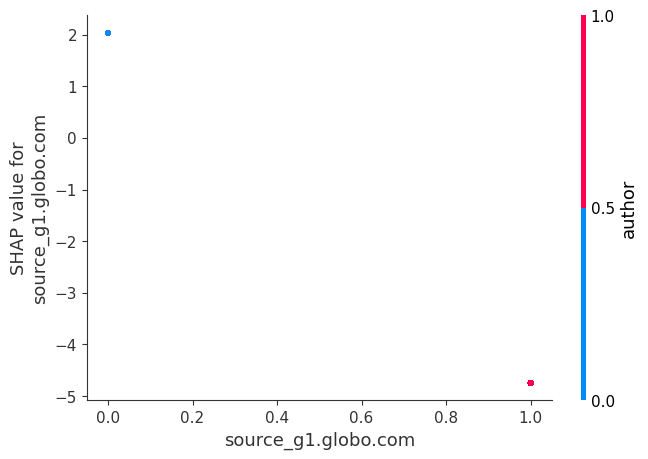

In [74]:
shap.dependence_plot('source_g1.globo.com', shap_values_context.values, X_context)

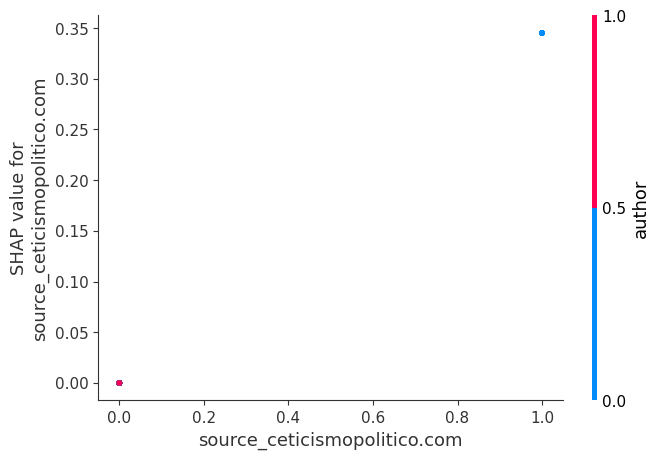

In [75]:
shap.dependence_plot('source_ceticismopolitico.com', shap_values_context.values, X_context)

In [76]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_context, X_context, show=False)
plt.savefig("figures/figures_extracao_pos/summaryplot_context_variables.pdf")

## Conteúdo + Contexto

In [77]:
general_model_results,general_model_name,general_model= get_best_model(X_train,y_train)

Modelo: Gradient Boosting
Modelo: GradientBoostingClassifier(random_state=0)
Accuracy: 0.9990740740740741
F1 Score: 0.9990791896869244
Recall: 1.0
Precision: 0.9981600735970562


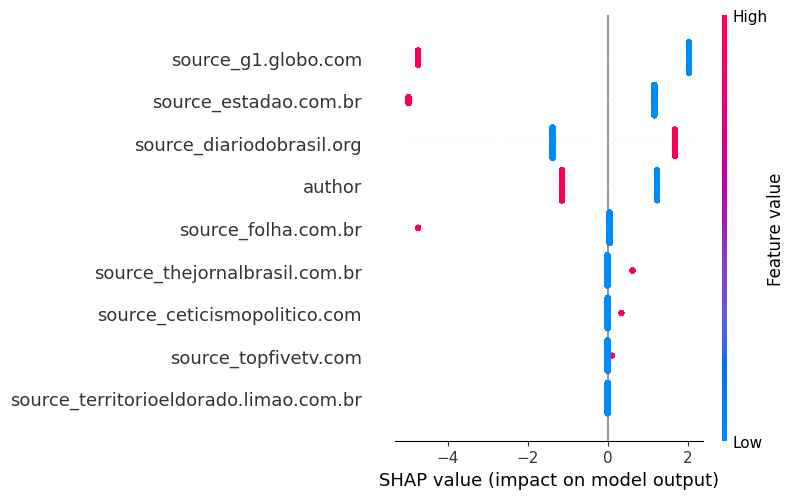

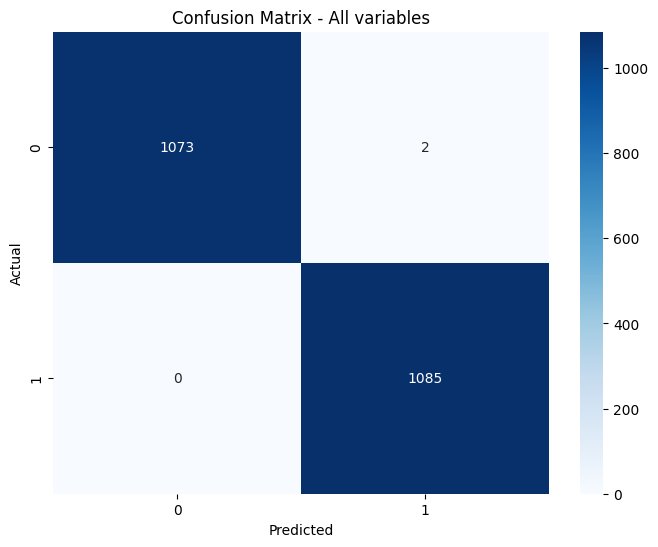

In [78]:
get_test_results(general_model_name,general_model,X_train,X_test,y_train,y_test)

### Explicabilidade do Conteúdo + Contexto — LIME com contexto fixo

O modelo combinado mistura dimensões de embedding (opacas) com features de contexto pequenas e interpretáveis (fonte/autor/data). `LimeTextExplainer` só perturba texto, então fixamos o contexto da notícia escolhida e perturbamos só o texto: a explicação responde "o que no texto moveu essa predição combinada, dado o contexto fixo desta notícia" — é uma explicação condicional por notícia, não uma afirmação agregada sobre o peso geral de conteúdo vs. contexto (essa afirmação agregada já vem do SHAP do cenário Contexto, acima).

A notícia escolhida é, entre as com entre 100 e 400 palavras, aquela em que o modelo de Conteúdo e o modelo Geral (Conteúdo + Contexto) predizem **classes opostas** (ex.: Conteúdo → fake, Geral → real), com maior diferença entre as probabilidades. Isso maximiza o contraste entre a representação puramente textual e a predição que inclui o contexto.

In [93]:
from sklearn.base import clone

# classifiers{} compartilhado: se o mesmo tipo de modelo venceu cenarios diferentes,
# content_model e general_model podem ser o mesmo objeto Python. Clona antes de refitar
# para que o fit de um nao sobrescreva o estado do outro (ambos usados nesta celula).
_cm  = clone(content_model).fit(X_train_content, y_train_content)
_gen = clone(general_model).fit(X_train, y_train)

candidatos_combinado = df_train_content.reset_index()[['id_noticia', 'noticia']].copy()
candidatos_combinado['n_palavras'] = candidatos_combinado['noticia'].str.split().apply(len)
# nao resetar o index aqui: candidatos_combinado.index ja corresponde a posicao da linha em
# X_train_content/X_train (mesma ordem de df_train_content), e e usado abaixo via .loc / []
candidatos_combinado = candidatos_combinado[
    (candidatos_combinado['n_palavras'] >= 150) &
    (candidatos_combinado['n_palavras'] <= 400)
]

proba_content = _cm.predict_proba(X_train_content.loc[candidatos_combinado.index])[:, 1]
proba_general = _gen.predict_proba(X_train[candidatos_combinado.index.to_numpy()])[:, 1]
candidatos_combinado['proba_content_fake'] = proba_content
candidatos_combinado['proba_general_fake'] = proba_general
# Noticia verdadeira (label=0) onde conteudo prevê fake e geral (acertando) prevê real
candidatos_combinado = candidatos_combinado[
    (candidatos_combinado['proba_content_fake'] >= 0.5) &
    (candidatos_combinado['proba_general_fake'] <  0.5) &
    (y_train_content.loc[candidatos_combinado.index].values == 0)
]
candidatos_combinado['diferenca_abs'] = (candidatos_combinado['proba_content_fake'] - candidatos_combinado['proba_general_fake']).abs()
candidatos_combinado = candidatos_combinado.sort_values('diferenca_abs', ascending=False)

linha_exemplo = candidatos_combinado.iloc[0]
id_exemplo_combinado = linha_exemplo['id_noticia']
texto_exemplo_combinado = linha_exemplo['noticia']
posicao_exemplo_combinado = linha_exemplo.name
print(linha_exemplo)

id_noticia                                                         5144
noticia               Lenha pra fogueira inimiga  Ao pedir tropas pa...
n_palavras                                                          156
proba_content_fake                                              0.91916
proba_general_fake                                              0.00007
diferenca_abs                                                  0.919091
Name: 4498, dtype: object


In [94]:
# Refit defensivo: os clones da celula anterior nao alteram os objetos globais, mas
# garante que general_model esta com todas as features corretas antes do LIME combinado.
general_model.fit(X_train, y_train)

context_train_columns = X_train_context.columns.tolist()

# contexto_fixo ja vem de X_train_context, ja na escala final (0-1) usada pelo modelo treinado -
# soh a parte de embedding do texto perturbado precisa ser escalada (via escalar_embeddings), o
# contexto fixo entra direto, sem passar por train_scaler.transform() de novo.
contexto_fixo = X_train_context.loc[posicao_exemplo_combinado][context_train_columns]

def predict_fn_combined(texts):
    novos_embeddings = model_st.encode(list(texts))
    novos_embeddings_escalados = escalar_embeddings(novos_embeddings)
    n = len(texts)
    novo_df = pd.DataFrame(novos_embeddings_escalados, columns=emb_cols)
    contexto_tiled = pd.DataFrame([contexto_fixo.values] * n, columns=context_train_columns)
    novo_df_full = pd.concat([novo_df, contexto_tiled], axis=1).reindex(columns=general_train_columns, fill_value=0)
    return general_model.predict_proba(novo_df_full.values)


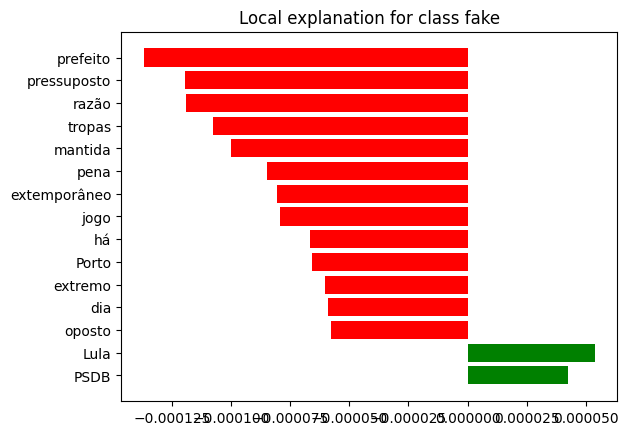

--------------------------------------------------------------------------------
Noticia selecionada (id=5144)
--------------------------------------------------------------------------------
Lenha pra fogueira inimiga  Ao pedir tropas para proteger Porto Alegre no dia do
julgamento de Lula, prefeito faz jogo do réu  O pedido do prefeito de Porto
Alegre, Nelson Marchezan Jr., do PSDB, para o governo federal enviar tropas do
Exército e homens da Força Nacional para a cidade no dia do julgamento de Lula,
é extemporâneo e fora de propósito. Só serve para por mais lenha na fogueira que
o PT pretende armar nas ruas e parte do pressuposto de que há clima para isso.
As mobilizações recentes tentando mostrar que o PT poderá por fogo no País se a
condenação de Lula for mantida, especialmente se o for por 3 a 0 e a pena for
mantida ou ampliada comprovam que não há, a não ser por parte do partido dele e
de seus adversários do extremo oposto, da direita, não têm razão de ser. Parece
ser o caso do 

In [95]:
explainer_combinado_lime = LimeTextExplainer(class_names=['true', 'fake'],
                                             split_expression=_lime_tokenizer)
explicacao_combinada = explainer_combinado_lime.explain_instance(
    texto_exemplo_combinado, predict_fn_combined, num_features=15, num_samples=5000
)
explicacao_combinada.as_pyplot_figure()
plt.savefig(f'figures/figures_embeddings/lime_combinado_{id_exemplo_combinado}.pdf', bbox_inches='tight')
plt.show()

import textwrap
print("-" * 80)
print(f"Noticia selecionada (id={id_exemplo_combinado})")
print("-" * 80)
print(textwrap.fill(texto_exemplo_combinado, width=80))
print("-" * 80)

## Validação Externa — FakeRecogna

Avalia os três modelos treinados no Fake.BR (Conteúdo por BERTimbau, Contexto, Geral) contra o FakeRecogna (11.902 notícias externas). A diferença em relação ao `validacao_externa.ipynb` é que o Conteúdo aqui é representado por embeddings densos, não pelas 21 features lingüísticas.

Pontos importantes:
- **Polaridade invertida** no FakeRecogna: `Classe` 0=fake, 1=real → `fake = 1 - Classe`.
- **Sem refit no FakeRecogna**: `train_scaler` é o mesmo fitado no treino do Fake.BR. Os embeddings brutos do FakeRecogna passam por `train_scaler.transform()` igual aos do Fake.BR — mesmo espaço de representação BERTimbau, mesma escala.
- **Source dummies**: os domínios do FakeRecogna raramente coincidem com os do Fake.BR, portanto todas ficam em `fill_value=0` após o `reindex`.
- **Explicabilidade de Conteúdo**: LIME (`predict_fn_content`) em vez de SHAP, pois dimensões de embedding não têm leitura humana individual.

In [82]:
import requests

FAKERECOGNA_URL = "https://raw.githubusercontent.com/Gabriel-Lino-Garcia/FakeRecogna/master/dataset/FakeRecogna_no_removal_words.xlsx"
FAKERECOGNA_PATH = "FakeRecogna_no_removal_words.xlsx"

if not os.path.exists(FAKERECOGNA_PATH):
    print("Baixando FakeRecogna...")
    resposta = requests.get(FAKERECOGNA_URL, timeout=120)
    resposta.raise_for_status()
    with open(FAKERECOGNA_PATH, "wb") as f:
        f.write(resposta.content)
    print(f"Baixado: {len(resposta.content)/1e6:.1f} MB")
else:
    print(f"FakeRecogna ja presente: {FAKERECOGNA_PATH}")

FakeRecogna ja presente: FakeRecogna_no_removal_words.xlsx


In [83]:
df_fr = pd.read_excel(FAKERECOGNA_PATH)
print(df_fr.shape, df_fr.columns.tolist())
df_fr = df_fr.dropna(subset=['Noticia']).copy()
df_fr['noticia'] = df_fr['Noticia'].astype(str).str.strip()
df_fr['fake']    = 1 - df_fr['Classe'].astype(int)  # polaridade invertida
df_fr['link']    = df_fr['URL']
df_fr = df_fr.reset_index(drop=True)
print(df_fr['fake'].value_counts())

(11902, 8) ['Titulo', 'Subtitulo', 'Noticia', 'Categoria', 'Data', 'Autor', 'URL', 'Classe']
fake
1    5951
0    5951
Name: count, dtype: int64


In [84]:
df_fr['source'] = df_fr['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]
df_fr['source'] = df_fr['source'].apply(
    lambda i: "estadao.com.br" if pd.notna(i) and "estadao" in str(i).lower()
    else "folha.com.br" if pd.notna(i) and "folha" in str(i).lower() and "uol" in str(i).lower()
    else i
)

df_fr['author'] = df_fr['Autor'].apply(
    lambda i: 0 if (pd.isna(i) or str(i).strip() == '' or str(i).strip().lower() in ('none', 'nan')) else 1
)

# O teste de hipotese para continuas (cell 53) pode dropar date_of_publication se nao
# for estatisticamente significativa. So extrai e preenche se ela e feature ativa.
if 'date_of_publication' in general_train_columns:
    date_of_publication_train_mean = df_train['date_of_publication'].mean()
    data_extraida = df_fr['Data'].astype(str).str.extract(r'(\d{1,2}/\d{1,2}/\d{4})')[0]
    df_fr['date_of_publication'] = pd.to_datetime(data_extraida, errors='coerce', dayfirst=True)
    print('Datas nao reconhecidas:', df_fr['date_of_publication'].isna().sum(), 'de', len(df_fr))
    df_fr['date_of_publication'] = df_fr['date_of_publication'].apply(
        lambda i: int(i.timestamp()) if pd.notna(i) else int(date_of_publication_train_mean)
    )
else:
    print('date_of_publication removida pelo teste de hipotese — nao e feature ativa')


date_of_publication removida pelo teste de hipotese — nao e feature ativa


In [85]:
inicio = time.time()
fr_embeddings = model_st.encode(df_fr["noticia"].tolist(), batch_size=batch_size, show_progress_bar=True)
print(f"Encoding concluido em {time.time()-inicio:.1f}s para {len(df_fr)} noticias (device={device})")

# Monta matrix de features: embeddings brutos + contexto bruto, alinha com general_train_columns
# e aplica train_scaler.transform() — mesmo scaler fitado no treino do Fake.BR.
df_fr_emb     = pd.DataFrame(fr_embeddings, columns=emb_cols, index=df_fr.index)
df_fr_dummies = pd.get_dummies(df_fr["source"], prefix="source")

# date_of_publication pode ter sido removida pelo teste de hipotese (nao e feature ativa).
# So inclui no concat se estiver presente em df_fr (preenchida na celula anterior).
context_cols_fr = ["author"] + (["date_of_publication"] if "date_of_publication" in df_fr.columns else [])
df_fr_raw     = pd.concat([df_fr_emb, df_fr[context_cols_fr], df_fr_dummies], axis=1)
df_fr_aligned = df_fr_raw.reindex(columns=general_train_columns, fill_value=0).fillna(0)

X_fr_scaled = pd.DataFrame(
    train_scaler.transform(df_fr_aligned),
    columns=general_train_columns,
    index=df_fr.index,
)

X_fr_content = X_fr_scaled[content_train_columns]
X_fr_context = X_fr_scaled[context_train_columns]
X_fr_general = X_fr_scaled[general_train_columns]
y_fr         = df_fr["fake"].astype(int)
print("X_fr_content:", X_fr_content.shape)
print("X_fr_context:", X_fr_context.shape)
print("X_fr_general:", X_fr_general.shape)


Batches: 100%|██████████| 1488/1488 [08:30<00:00,  2.91it/s]


Encoding concluido em 511.0s para 11902 noticias (device=cuda)
X_fr_content: (11902, 768)
X_fr_context: (11902, 9)
X_fr_general: (11902, 777)


### Avaliação no FakeRecogna

Reusa `get_test_results` para refittar cada modelo nos dados de treino do Fake.BR e avaliar contra o FakeRecogna. As chamadas são sequenciais: se o mesmo tipo de modelo venceu cenários diferentes (`classifiers{}` compartilhado), o refit do cenário seguinte corrompe o anterior — mas cada avaliação já está concluída antes do próximo refit.

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.5052932280289028
F1 Score: 0.6679075014100395
Recall: 0.9949588304486641
Precision: 0.5026742507852958


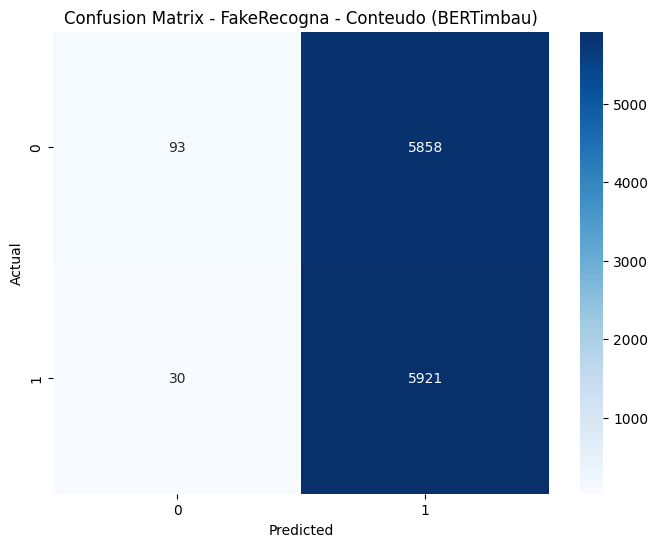

In [86]:
get_test_results(content_model_name, content_model,
                 X_train_content, X_fr_content, y_train_content, y_fr,
                 "FakeRecogna - Conteudo (BERTimbau)")

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.49294236262812974
F1 Score: 0.612370736720406
Recall: 0.8010418417072761
Precision: 0.49563318777292575


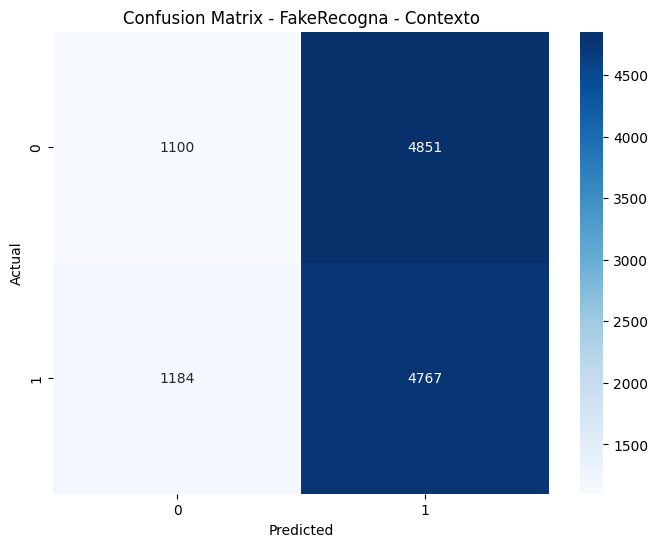

In [87]:
get_test_results(context_model_name, context_model,
                 X_train_context, X_fr_context, y_train_context, y_fr,
                 "FakeRecogna - Contexto")

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Modelo: Gradient Boosting
Modelo: GradientBoostingClassifier(random_state=0)
Accuracy: 0.49294236262812974
F1 Score: 0.612370736720406
Recall: 0.8010418417072761
Precision: 0.49563318777292575


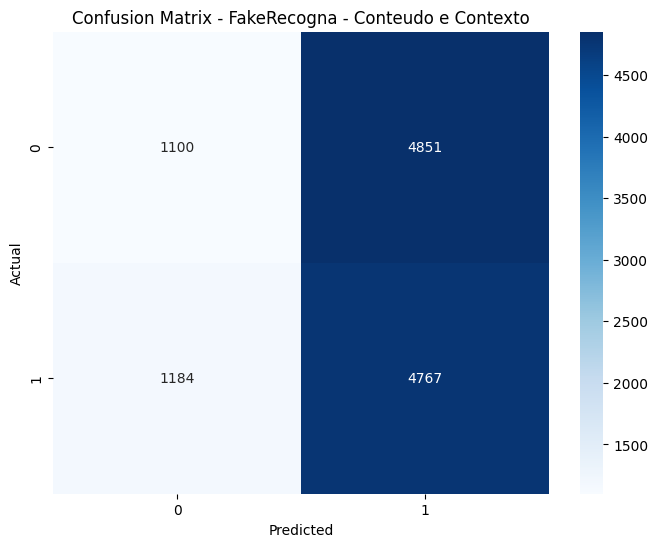

In [88]:
get_test_results(general_model_name, general_model,
                 X_train, X_fr_general, y_train, y_fr,
                 "FakeRecogna - Conteudo e Contexto")

### Explicabilidade no FakeRecogna

As avaliações acima mostram *quanto* os modelos acertam no FakeRecogna, mas não *como* tomam as decisões. Esta seção usa SHAP para Contexto (features interpretáveis) e LIME para Conteúdo (embeddings opacas → explicação em espaço de palavras).

A célula abaixo verifica quais source dummies do Fake.BR estão ativas no FakeRecogna antes de interpretar o SHAP — se todas forem 0, o modelo de Contexto está tomando decisões essencialmente baseado em `author` e `date_of_publication`.

In [89]:
source_cols = [c for c in context_train_columns if c.startswith('source_')]
fr_source_ativo = (X_fr_context[source_cols] > 0).any(axis=0)
print(f'Source dummies treinadas no Fake.BR: {len(source_cols)}')
print(f'Dessas, com pelo menos 1 artigo ativo no FakeRecogna: {fr_source_ativo.sum()}')
ativos = fr_source_ativo[fr_source_ativo].index.tolist()
print('Dummies ativas:', ativos if ativos else '(nenhuma — todos os artigos do FakeRecogna tem source dummies em 0)')
n_com_source = (X_fr_context[source_cols] > 0).any(axis=1).sum()
print(f'Artigos com ao menos uma source dummy ativa: {n_com_source} de {len(X_fr_context)} ({100*n_com_source/len(X_fr_context):.1f}%)')

Source dummies treinadas no Fake.BR: 8
Dessas, com pelo menos 1 artigo ativo no FakeRecogna: 1
Dummies ativas: ['source_g1.globo.com']
Artigos com ao menos uma source dummy ativa: 2284 de 11902 (19.2%)


#### SHAP — Contexto no FakeRecogna

Três gráficos, espelhando o `validacao_externa`:
- **Beeswarm summary**: quais features de contexto guiam as predições no FakeRecogna (e em que direção). Se todas as source dummies forem 0, as barras longas serão `author` e/ou `date_of_publication`.
- **Dependence plot de `author`**: testa diretamente a hipótese de viés de fonte — se `author=1` tiver SHAP consistentemente negativo, o modelo aprendeu que "assinado → real" de forma geral.
- **Force plots** da predição correta mais confiante e da errada mais confiante.

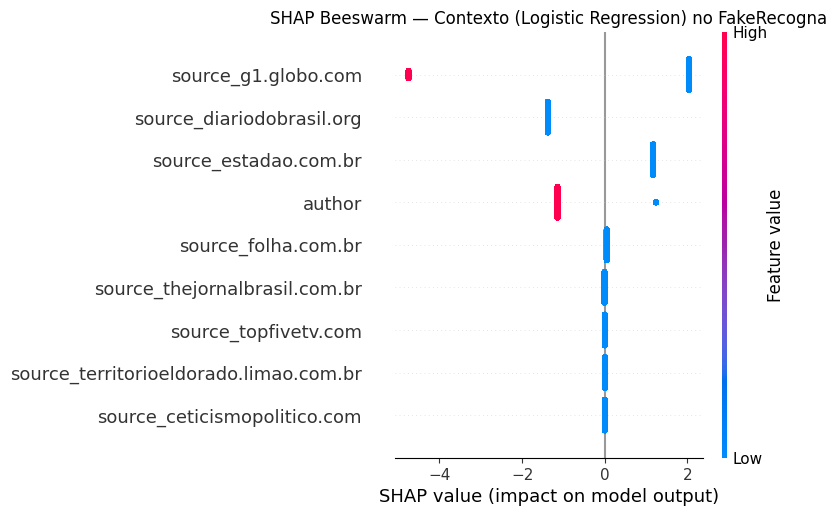

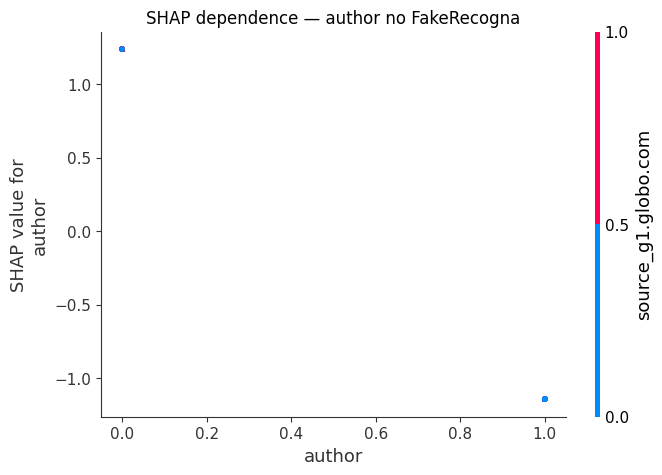

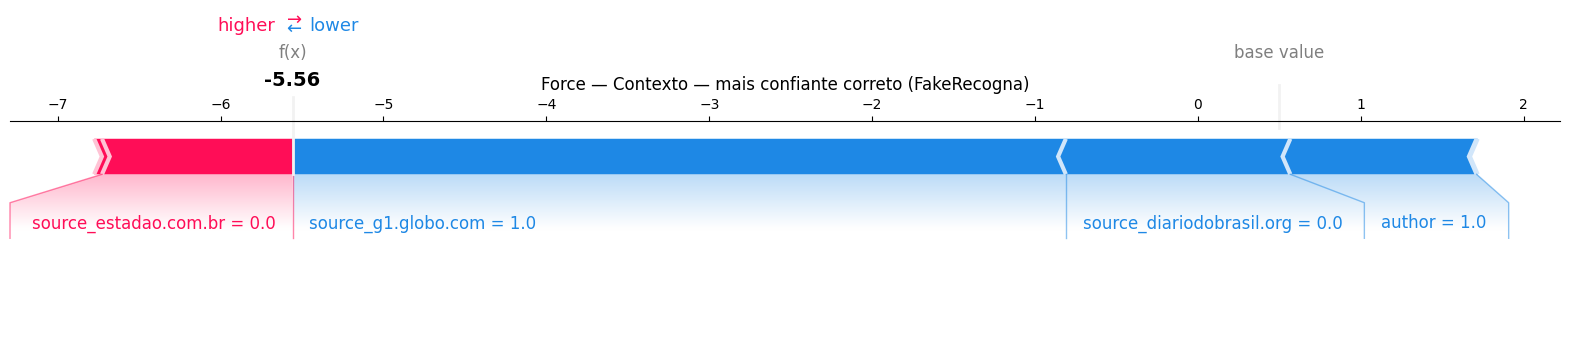

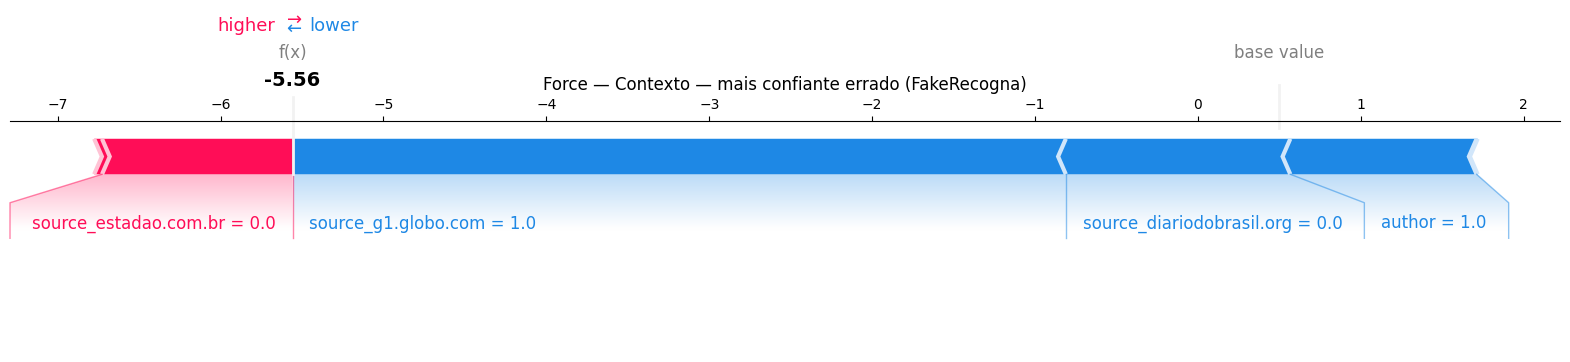

In [90]:
import shap

def _shap_values_class1(model, X_train, X_test):
    """SHAP values para classe 1 (fake): Tree → Linear → Kernel em cascata."""
    if hasattr(model, 'estimators_'):
        exp = shap.TreeExplainer(model)
        sv = exp.shap_values(X_test)
    else:
        try:
            exp = shap.LinearExplainer(model, X_train)
            sv = exp.shap_values(X_test)
        except (ValueError, AttributeError, TypeError):
            if hasattr(model, 'predict_proba'):
                fn = model.predict_proba
            else:
                def fn(X):
                    d = model.decision_function(X)
                    p = 1.0 / (1.0 + np.exp(-d))
                    return np.column_stack([1 - p, p])
            bg = shap.sample(X_train, min(100, len(X_train)))
            exp = shap.KernelExplainer(fn, bg)
            sv = exp.shap_values(X_test)
    if isinstance(sv, list):
        sv = sv[1]
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

def _proba_class1(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    d = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-d))

# Refit context_model com features corretas antes do SHAP
# (get_test_results do cenario Geral pode ter corrompido o objeto compartilhado)
context_model.fit(X_train_context, y_train_context)
sv_ctx_fr = _shap_values_class1(context_model, X_train_context, X_fr_context)

# ── Beeswarm ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
shap.summary_plot(sv_ctx_fr, X_fr_context, show=False)
plt.title(f'SHAP Beeswarm — Contexto ({context_model_name}) no FakeRecogna')
plt.savefig('figures/figures_embeddings/shap_context_beeswarm_fakerecogna.pdf', bbox_inches='tight')
plt.show()

# ── Dependence: author ─────────────────────────────────────────────────────────
if 'author' in X_fr_context.columns:
    shap.dependence_plot('author', sv_ctx_fr, X_fr_context, show=False)
    plt.title('SHAP dependence — author no FakeRecogna')
    plt.savefig('figures/figures_embeddings/shap_dep_author_fakerecogna.pdf', bbox_inches='tight')
    plt.show()

# ── Force plots ───────────────────────────────────────────────────────────────
proba_ctx_fr = _proba_class1(context_model, X_fr_context)
pred_ctx_fr  = (proba_ctx_fr >= 0.5).astype(int)
base_ctx_fr  = _proba_class1(context_model, X_train_context).mean()
y_fr_arr     = y_fr.values

corretos_ctx = np.where(pred_ctx_fr == y_fr_arr)[0]
errados_ctx  = np.where(pred_ctx_fr != y_fr_arr)[0]

for idx, rotulo in [
    (corretos_ctx[np.argmax(np.abs(proba_ctx_fr[corretos_ctx] - 0.5))] if len(corretos_ctx) else None, 'correto'),
    (errados_ctx[np.argmax(np.abs(proba_ctx_fr[errados_ctx] - 0.5))]   if len(errados_ctx)  else None, 'errado'),
]:
    if idx is None:
        continue
    shap.plots.force(
        base_value=base_ctx_fr,
        shap_values=sv_ctx_fr[idx],
        features=np.round(X_fr_context.iloc[idx].values, 3),
        feature_names=X_fr_context.columns.tolist(),
        matplotlib=True, show=False,
    )
    plt.title(f'Force — Contexto — mais confiante {rotulo} (FakeRecogna)')
    plt.savefig(f'figures/figures_embeddings/force_context_{rotulo}_fakerecogna.pdf', bbox_inches='tight')
    plt.show()

#### LIME: Conteúdo (BERTimbau) no FakeRecogna

Usa `predict_fn_content` (pipeline texto → BERTimbau → escala → content_model) para explicar uma notícia do FakeRecogna. Escolhe a notícia com maior confiança do modelo (predição mais afastada de 0,5), entre as com 100 a 400 palavras, classificada corretamente pelo modelo de conteúdo.

Artigo selecionado: idx=11329, n_palavras=119, confianca=0.500
Label real: 1 (fake=1), predito: 1


c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


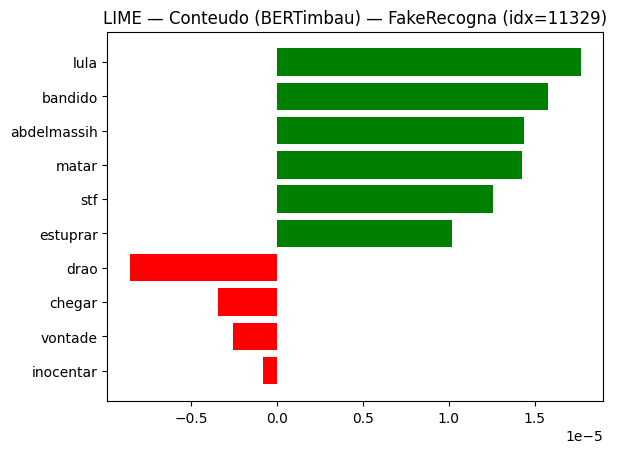

--------------------------------------------------------------------------------
Noticia selecionada (id=11329)
--------------------------------------------------------------------------------
o nardoni matar criança inocentar ruir parabém o o stf … olhar stf soltar b …
matar o filho … pra soltar o otário lula … ptzada … bora libertar o lula*drao ”
… chegar ficar vontade vomitar tamanho nojeira stf e gangue atitude … sair o
pobre coitar roger abdelmassih estuprar né esquecer o p … lula e bolsonaro m …
político lula livrar e montar bandido juntar prabens ótimo trabalhar stf pra
defender lula criminoso beneficiar absurdo decisão stf.mais “ inocentar ” deixar
o prisão o decisão stf derrubar o prisão instância o m … começar o vazar … vivo
m … e filho puta stf … o lula preocupar o m … juntar n barca supremo
--------------------------------------------------------------------------------


In [91]:
from lime.lime_text import LimeTextExplainer

# Refit content_model com features corretas antes de predict_fn_content
# (context_model.fit acima pode ter corrompido o objeto se forem o mesmo)
content_model.fit(X_train_content, y_train_content)

proba_fr_c   = _proba_class1(content_model, X_fr_content)
pred_fr_c    = (proba_fr_c >= 0.5).astype(int)

df_fr_cands_c = df_fr[['noticia']].copy()
df_fr_cands_c['n_palavras'] = df_fr_cands_c['noticia'].str.split().apply(len)
df_fr_cands_c['correto']    = (pred_fr_c == y_fr_arr).astype(int)
# Verdadeiros positivos: noticia fake (label=1) corretamente classificada como fake (pred=1)
df_fr_cands_c = df_fr_cands_c[
    (df_fr_cands_c['correto'] == 1) &
    (df_fr_cands_c['n_palavras'] >= 100) &
    (df_fr_cands_c['n_palavras'] <= 400) &
    (y_fr.loc[df_fr_cands_c.index] == 1)
].copy()
df_fr_cands_c['confianca'] = (pd.Series(proba_fr_c, index=df_fr.index).loc[df_fr_cands_c.index] - 0.5).abs()
df_fr_cands_c = df_fr_cands_c.sort_values('confianca', ascending=False)

idx_fr_content   = df_fr_cands_c.index[0]
texto_fr_content = df_fr_cands_c.iloc[0]['noticia']
print(f'Artigo selecionado: idx={idx_fr_content}, n_palavras={df_fr_cands_c.iloc[0]["n_palavras"]}, confianca={df_fr_cands_c.iloc[0]["confianca"]:.3f}')
print(f'Label real: {y_fr.loc[idx_fr_content]} (fake=1), predito: {pred_fr_c[idx_fr_content]}')

explainer_fr_c = LimeTextExplainer(class_names=['true', 'fake'],
                            split_expression=_lime_tokenizer)
explicacao_fr_c = explainer_fr_c.explain_instance(
    texto_fr_content, predict_fn_content, num_features=10, num_samples=500
)
explicacao_fr_c.as_pyplot_figure()
plt.title(f'LIME — Conteudo (BERTimbau) — FakeRecogna (idx={idx_fr_content})')
plt.savefig(f'figures/figures_embeddings/lime_content_fakerecogna_{idx_fr_content}.pdf', bbox_inches='tight')
plt.show()

import textwrap
print("-" * 80)
print(f"Noticia selecionada (id={idx_fr_content})")
print("-" * 80)
print(textwrap.fill(texto_fr_content, width=80))
print("-" * 80)

#### LIME — Conteúdo + Contexto no FakeRecogna

Mesma lógica do LIME combinado de treino: fixa o contexto de um artigo do FakeRecogna e perturba só o texto. Seleciona, entre as notícias com entre 100 e 400 palavras, aquela em que o modelo de Conteúdo e o modelo Geral predizem **classes opostas** (ex.: Conteúdo → fake, Geral → real) — torna o contraste entre visão puramente textual e predição combinada mais ilustrativo num corpus externo.

Usa `clone()` para selecionar o artigo sem alterar o estado global, depois refita `general_model` com `X_train` para o `predict_fn_combined_fr`.

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


noticia               o engenheiro florestal tasso azevedo especiali...
n_palavras                                                          100
proba_content_fake                                             0.999994
proba_general_fake                                             0.000068
diferenca_abs                                                  0.999926
Name: 7260, dtype: object


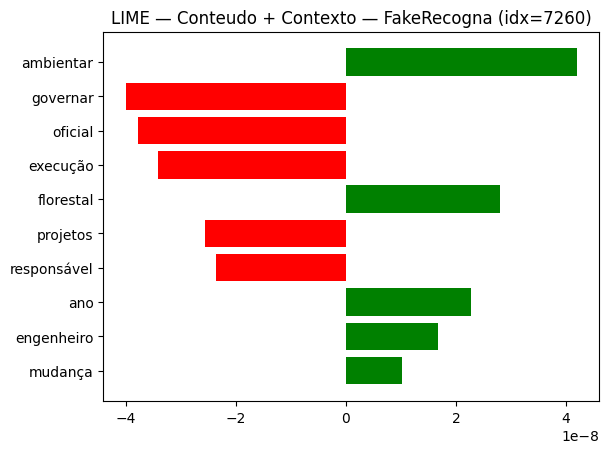

--------------------------------------------------------------------------------
Noticia selecionada (id=7260)
--------------------------------------------------------------------------------
o engenheiro florestal tasso azevedo especialista observatório clima e ex-
diretor serviço florestal brasileiro sfb avaliar “ trágico ” o exclusão
sociedade civil deliberativo fundir nacional ambientar fnma “ trágico ...
governar fechar si grau ineficiência e execução absurdo ” crítico o
ambientalista o decretar o mudança fnma publicar n quinta-feira diário oficial
união o fundir administrar ministério ambientar e responsável fomentar o
desenvolvimento atividades sustentável país distribuir verba arrecadar concessão
florestar “ governar recurso conseguir aplicar e conseguir executar instrumentar
o fundir nacional ambientar ano existência e zilhões projetos e desmantelar o
execução ano passar literalmente ” afirmar tasso azevedo
----------------------------------------------------------------------

In [92]:
from sklearn.base import clone

# Clones locais para selecao de candidatos (evita corrupcao mutua se mesmos objetos)
_cm_fr  = clone(content_model).fit(X_train_content, y_train_content)
_gen_fr = clone(general_model).fit(X_train, y_train)

df_fr_cands = df_fr[['noticia']].copy()
df_fr_cands['n_palavras'] = df_fr_cands['noticia'].str.split().apply(len)
df_fr_cands = df_fr_cands[
    (df_fr_cands['n_palavras'] >= 100) &
    (df_fr_cands['n_palavras'] <= 400)
].copy()

proba_fr_cands_c   = _proba_class1(_cm_fr,  X_fr_content.loc[df_fr_cands.index])
proba_fr_cands_gen = _proba_class1(_gen_fr, X_fr_general.loc[df_fr_cands.index])
df_fr_cands['proba_content_fake'] = proba_fr_cands_c
df_fr_cands['proba_general_fake'] = proba_fr_cands_gen
# Noticia verdadeira (label=0) onde conteudo prevê fake e geral (acertando) prevê real
df_fr_cands = df_fr_cands[
    (df_fr_cands['proba_content_fake'] >= 0.5) &
    (df_fr_cands['proba_general_fake'] <  0.5) &
    (y_fr.loc[df_fr_cands.index] == 0)
]
df_fr_cands['diferenca_abs'] = (df_fr_cands['proba_content_fake'] - df_fr_cands['proba_general_fake']).abs()
df_fr_cands = df_fr_cands.sort_values('diferenca_abs', ascending=False)

linha_fr_comb   = df_fr_cands.iloc[0]
idx_fr_comb     = linha_fr_comb.name
texto_fr_comb   = linha_fr_comb['noticia']
print(linha_fr_comb)

# Refita general_model com todas as features para o predict_fn_combined_fr
general_model.fit(X_train, y_train)

contexto_fr_fixo = X_fr_context.loc[idx_fr_comb][context_train_columns]

def predict_fn_combined_fr(texts):
    novos_embeddings = model_st.encode(list(texts))
    novos_embeddings_escalados = escalar_embeddings(novos_embeddings)
    n = len(texts)
    novo_df = pd.DataFrame(novos_embeddings_escalados, columns=emb_cols)
    contexto_tiled = pd.DataFrame([contexto_fr_fixo.values] * n, columns=context_train_columns)
    novo_df_full = pd.concat([novo_df, contexto_tiled], axis=1).reindex(columns=general_train_columns, fill_value=0)
    return general_model.predict_proba(novo_df_full.values)

explainer_fr_comb = LimeTextExplainer(class_names=['true', 'fake'],
                            split_expression=_lime_tokenizer)
explicacao_fr_comb = explainer_fr_comb.explain_instance(
    texto_fr_comb, predict_fn_combined_fr, num_features=10, num_samples=500
)
explicacao_fr_comb.as_pyplot_figure()
plt.title(f'LIME — Conteudo + Contexto — FakeRecogna (idx={idx_fr_comb})')
plt.savefig(f'figures/figures_embeddings/lime_combinado_fakerecogna_{idx_fr_comb}.pdf', bbox_inches='tight')
plt.show()

import textwrap
print("-" * 80)
print(f"Noticia selecionada (id={idx_fr_comb})")
print("-" * 80)
print(textwrap.fill(texto_fr_comb, width=80))
print("-" * 80)